**Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_digits
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

**Load dataset**

In [4]:
digits=load_digits()
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

<Figure size 640x480 with 0 Axes>

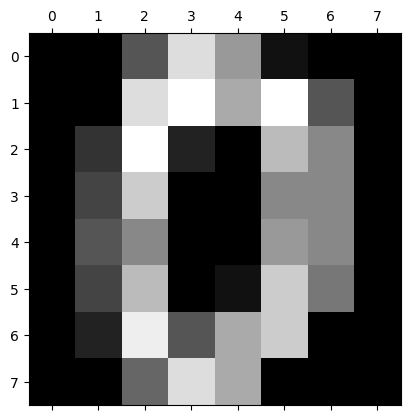

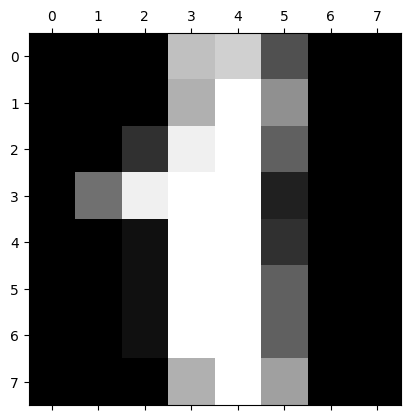

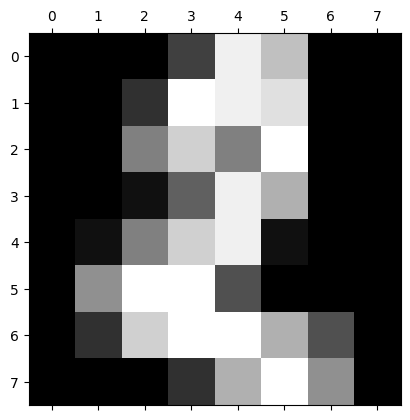

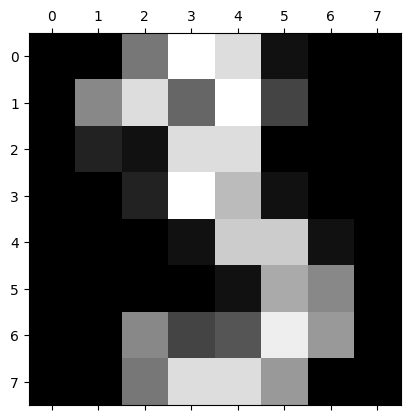

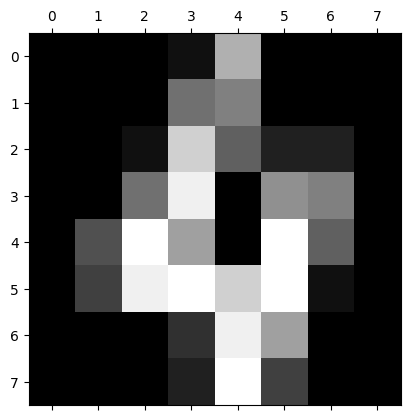

In [7]:
plt.gray()
for i in range(5):
    plt.matshow(digits.images[i])
    plt.show()

**Features and Target**

In [9]:
X=digits.data
y=digits.target

**Train Test Split**

In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Model**

In [13]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.9833333333333333

**Different K values**

In [20]:
scores=[]
maxi=float('-inf')
best_k=0
for k in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test, y_test)
    scores.append(score)
    print(k,score)
    if score>maxi:
      best_k=k
      maxi=score
print(best_k)

1 0.9777777777777777
2 0.9805555555555555
3 0.9833333333333333
4 0.9805555555555555
5 0.9861111111111112
6 0.9888888888888889
7 0.9888888888888889
8 0.9861111111111112
9 0.9805555555555555
10 0.9833333333333333
11 0.9833333333333333
12 0.9777777777777777
13 0.9777777777777777
14 0.9805555555555555
15 0.9777777777777777
16 0.9805555555555555
17 0.9833333333333333
18 0.9805555555555555
19 0.975
20 0.9777777777777777
6


**Visualise**

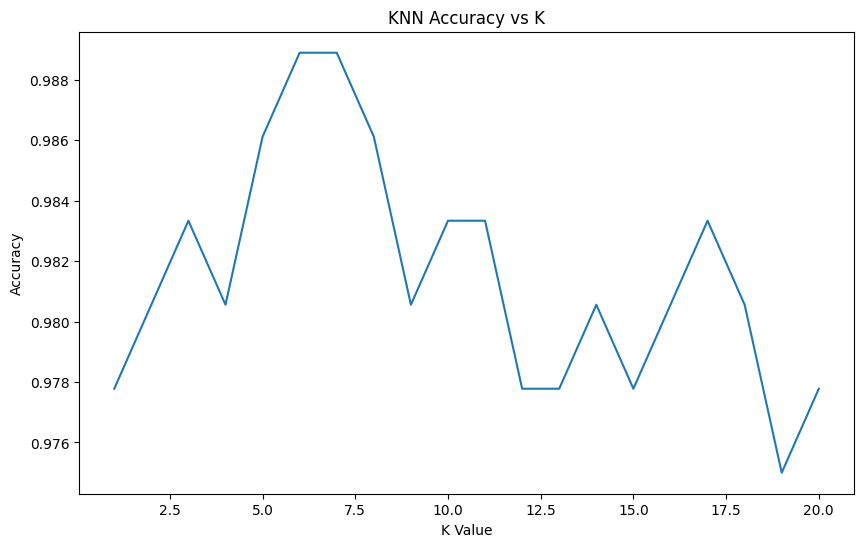

In [21]:
plt.figure(figsize=(10,6))
plt.plot(range(1,21), scores)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.show()

**GridSearchCV**

In [27]:
grid=GridSearchCV(KNeighborsClassifier(),{'n_neighbors': range(1,21)},cv=5)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)
best_model=grid.best_estimator_

{'n_neighbors': 1}
0.9860820751064654


**Predictions and Confusion matrix**

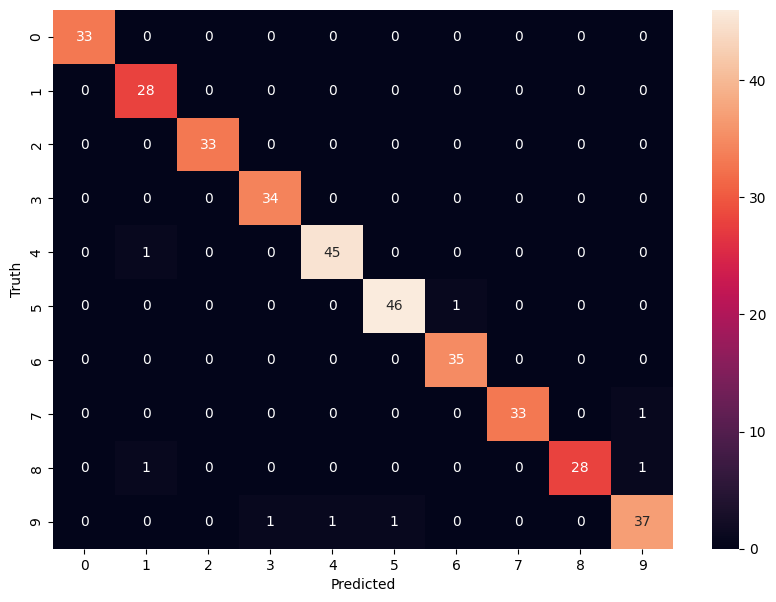

In [29]:
predictions=best_model.predict(X_test)
cm=confusion_matrix(y_test,predictions)
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()

**Classification**

In [30]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      0.98      0.98        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.93      0.97        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

